# Advertising Sales Prediction (Linear Regression)

###  About the Dataset

This dataset contains information about advertising budgets spent across different media channels and the resulting product sales. It has **200 rows** and the following **4 columns**:


---
## Import Required Libraries
- `numpy` — for numerical operations
- `pandas` — for loading and handling data
- `seaborn` — for creating plots
- `matplotlib.pyplot` — for displaying plots

In [ ]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

---
## Task 2 - Load the Dataset


```



In [ ]:
ad=pd.read_csv('/content/Advertising Budget and Sales.csv')

---
## Task 3 - Explore the Dataset

### - Display all column names
> Use `.columns` on your DataFrame.

In [ ]:
ad


,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [ ]:
ad.columns

Index(['Unnamed: 0', 'TV Ad Budget ($)', 'Radio Ad Budget ($)',
       'Newspaper Ad Budget ($)', 'Sales ($)'],
      dtype='object')

### - Check data types and non-null value counts for each column
> Use `.info()`

In [ ]:

ad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               200 non-null    int64  
 1   TV Ad Budget ($)         200 non-null    float64
 2   Radio Ad Budget ($)      200 non-null    float64
 3   Newspaper Ad Budget ($)  200 non-null    float64
 4   Sales ($)                200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


### - Display basic statistics: mean, min, max, standard deviation, etc.
> Use `.describe()`

In [ ]:
ad.describe()


,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


---
## Task 4 - Check Data Quality

### - Count duplicate rows in the dataset
> Use `.duplicated().sum()`

In [ ]:
ad.duplicated().sum()


np.int64(0)

### - Count missing (null) values in each column
> Use `.isnull().sum()`

In [ ]:
ad.isnull().sum()

,0
Unnamed: 0,0
TV Ad Budget ($),0
Radio Ad Budget ($),0
Newspaper Ad Budget ($),0
Sales ($),0


---
## Task 5 - Exploratory Data Analysis (EDA)

EDA means visually exploring the data to understand patterns **before** building a model.

---

### - Plot the Distribution of Sales

**What to do:**
Plot a histogram with a KDE (density) curve for the `Sales` column to understand how sales values are spread.

> Use `sns.histplot()` with `kde=True`. Add a title and axis labels.

Text(0, 0.5, 'Frequency')

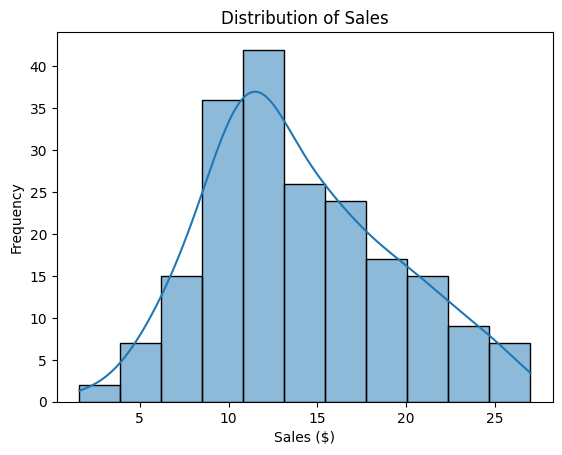

In [ ]:
sns.histplot(ad['Sales ($)'],kde=True)
plt.title('Distribution of Sales')
plt.xlabel('Sales ($)')
plt.ylabel('Frequency')

### - Scatter Plots: Each Feature vs Sales

**What to do:**
Create scatter plots for each of the 3 feature columns against `Sales` in a single figure.

Features to plot:
- `TV`
- `Radio`
- `Newspaper`

>  Store the column names in a list. Use a `for` loop with `plt.subplot(1, 3, i)` and `sns.scatterplot()`. Use `plt.figure(figsize=(18,5))` for a wider figure. Call `plt.tight_layout()` at the end.

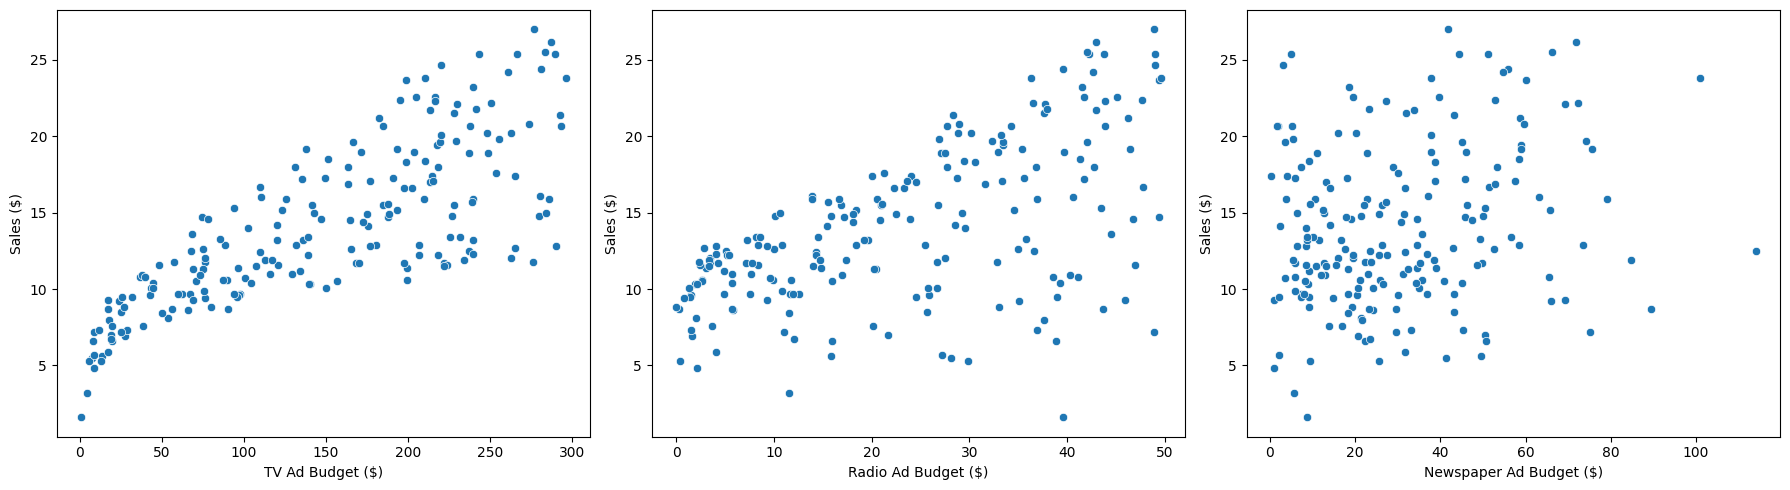

In [ ]:
plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
sns.scatterplot(x='TV Ad Budget ($)',y='Sales ($)',data=ad)
plt.subplot(1,3,2)
sns.scatterplot(x='Radio Ad Budget ($)',y='Sales ($)',data=ad)
plt.subplot(1,3,3)
sns.scatterplot(x='Newspaper Ad Budget ($)',y='Sales ($)',data=ad)
plt.tight_layout()

### - Boxplots: Check for Outliers in Each Feature

**What to do:**
Create a boxplot for each of the 3 feature columns to visually detect outliers.

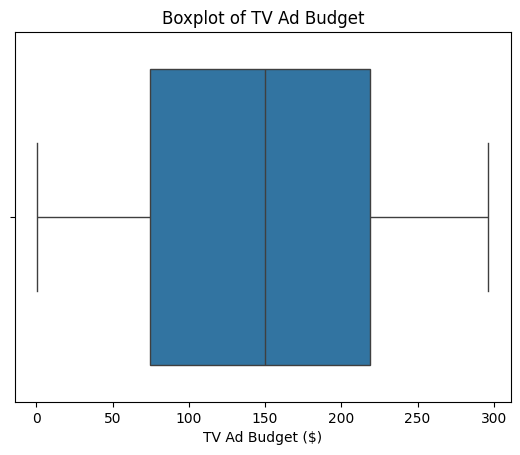

In [ ]:

sns.boxplot(x='TV Ad Budget ($)',data=ad)
plt.title('Boxplot of TV Ad Budget')
plt.show()

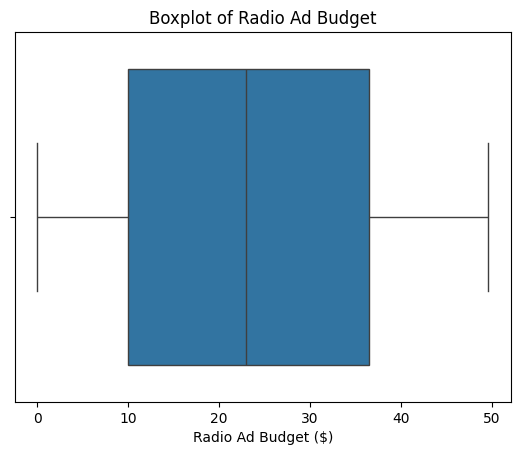

In [ ]:
sns.boxplot(x='Radio Ad Budget ($)',data=ad)
plt.title('Boxplot of Radio Ad Budget')
plt.show()

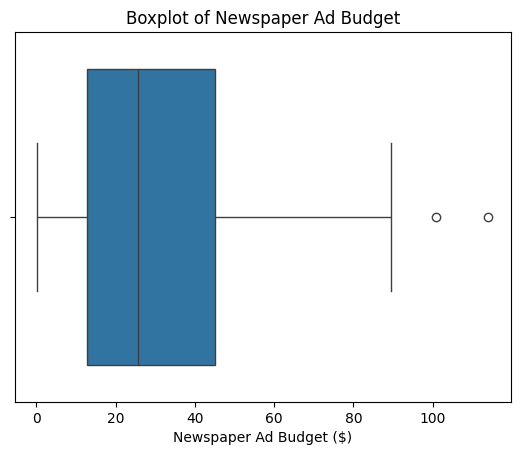

In [ ]:
sns.boxplot(x='Newspaper Ad Budget ($)',data=ad)
plt.title('Boxplot of Newspaper Ad Budget')
plt.show()

### - Correlation Heatmap

**What to do:**
Plot a heatmap showing the correlation between all columns. This helps you understand which features are most related to `Sales`.

> **Hint:** Use `sns.heatmap()` with `annot=True` so the numbers appear inside the boxes. Pass `df.corr(numeric_only=True)` as the data.

In [ ]:
ad=ad.drop('Unnamed: 0',axis=1, errors='ignore')

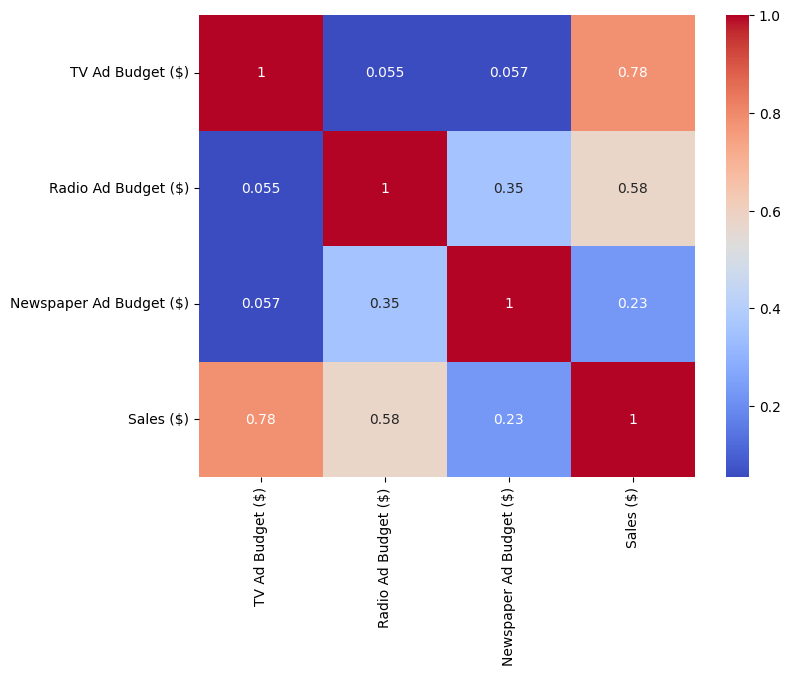

In [ ]:

plt.figure(figsize=(8,6))
sns.heatmap(ad.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.show()

---
## Task 6 - Define Features (X) and Target (y)

**What to do:**
- Create `X` — all columns **except** `Sales` (input features the model learns from)
- Create `y` — only the `Sales` column (the value to predict)
- Print the shape of both `X` and `y`

> Use `.drop('Sales', axis=1)` for X and `df['Sales']` for y.

In [ ]:
x=X = ad.drop('Sales ($)', axis=1)
y = ad['Sales ($)']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (200, 3)
y shape: (200,)


---
## Task 7 - Split Data into Training and Testing Sets

**What to do:**
Split `X` and `y` into 4 parts:
- `X_train`, `X_test` — input features for training and testing
- `y_train`, `y_test` — target values for training and testing


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train


,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($)
79,116.0,7.7,23.1
197,177.0,9.3,6.4
38,43.1,26.7,35.1
24,62.3,12.6,18.3
122,224.0,2.4,15.6
...,...,...,...
106,25.0,11.0,29.7
14,204.1,32.9,46.0
92,217.7,33.5,59.0
179,165.6,10.0,17.6


In [ ]:
y_train

,Sales ($)
79,11.0
197,12.8
38,10.1
24,9.7
122,11.6
...,...
106,7.2
14,19.0
92,19.4
179,12.6


---
## Task 8 - Feature Scaling

**What to do:**
Apply `StandardScaler` to scale the features:
- **Fit and transform** on `X_train` → save as `X_train_scaled`
- **Only transform** on `X_test` → save as `X_test_scaled`

> **Hint:** Import `StandardScaler` from `sklearn.preprocessing`. Create a scaler object, then use `.fit_transform()` for train and `.transform()` for test.

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

---
# Task 9
##1. Build the Linear Regression Model

### Train the Linear Regression Model

**What to do:**
Create a Linear Regression model and train it on the scaled training data.

> Import `LinearRegression` from `sklearn.linear_model`. Create the model using `LinearRegression()` and fit it using `.fit(X_train_scaled, y_train)`.

In [ ]:
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

LinearRegression()


## 2. Build the Ridge Regression Model

### Train the Ridge Regression Model

**What to do:**  
Create a Ridge Regression model and train it on the scaled training data.

> Import `Ridge` from Scikit-learn. Create the model using `Ridge(alpha=1.0)` and fit it using `.fit(X_train_scaled, y_train)`.



In [ ]:
from sklearn.linear_model import Ridge
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

Ridge()

## 3. Build the Lasso Regression Model

### Train the Lasso Regression Model

**What to do:**  
Create a Lasso Regression model and train it on the scaled training data.

> Import `Lasso` from Scikit-learn. Create the model using `Lasso(alpha=1.0)` and fit it using `.fit(X_train_scaled, y_train)`

In [ ]:
from sklearn.linear_model import Lasso
lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train_scaled, y_train)


Lasso()

---
## Task 10 - Make Predictions

### Generate Predictions for All Models

**What to do:**  
Use each trained model (Linear Regression, Ridge Regression, and Lasso Regression) to make predictions on both training and testing datasets.

- Predict on the test set → save as `y_pred_test`
- Predict on the training set → save as `y_pred_train`

> Use the `.predict()` method on scaled data (e.g., `X_test_scaled`, `X_train_scaled`) for each model separately.

**Note:**
Ensure predictions are generated for all three models and stored clearly (e.g., separate variables for each model).

In [ ]:
#linear
y_pred_test=linear_model.predict(X_test_scaled)
y_pred_train=linear_model.predict(X_train_scaled)

#ridge
y_pred_test_ridge=ridge_model.predict(X_test_scaled)
y_pred_train_ridge=ridge_model.predict(X_train_scaled)

#lasso
y_pred_test_lasso=lasso_model.predict(X_test_scaled)
y_pred_train_lasso=lasso_model.predict(X_train_scaled)


---
## Task 11 - Evaluate the Models

**What to do:**
Calculate and print the following metrics for both **test** and **train** predictions:

| Metric |
|---|
| **R² Score** |
| **MSE** |
| **MAE** |

> Import `r2_score`, `mean_squared_error`, `mean_absolute_error` from `sklearn.metrics`. Calculate train R² using `y_train` and `y_pred_train`.


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error



In [ ]:
print('-----linear regression----')

print('R2 score train',r2_score(y_train, y_pred_train))
print('R2 score test:', r2_score(y_test, y_pred_test))

print('MSE train:', mean_squared_error(y_train, y_pred_train))
print('MSE test:', mean_squared_error(y_test, y_pred_test))


print('MAE train', mean_absolute_error(y_train, y_pred_train))
print('MAE test:', mean_absolute_error(y_test, y_pred_test))

-----linear regression----
R2 score train 0.8957008271017817
R2 score test: 0.8994380241009119
MSE train: 2.705129423081414
MSE test: 3.174097353976106
MAE train 1.1984678961500133
MAE test: 1.4607567168117606


In [ ]:
print('-----ridge regression----')

print('R2 score train',r2_score(y_train, y_pred_train_ridge))
print('R2 score test:', r2_score(y_test, y_pred_test_ridge))

print('MSE train:', mean_squared_error(y_train, y_pred_train_ridge))
print('MSE test:', mean_squared_error(y_test, y_pred_test_ridge))


print('MAE train', mean_absolute_error(y_train, y_pred_train_ridge))
print('MAE test:', mean_absolute_error(y_test, y_pred_test_ridge))

-----ridge regression----
R2 score train 0.8956679557030848
R2 score test: 0.8988025280800618
MSE train: 2.7059819838958674
MSE test: 3.194155892207962
MAE train 1.1991784164288972
MAE test: 1.4643012916475109


In [ ]:
print('----lassso riggression')

print('R2 score train',r2_score(y_train, y_pred_train_lasso))
print('R2 score test:', r2_score(y_test, y_pred_test_lasso))

print('MSE train:', mean_squared_error(y_train, y_pred_train_lasso))
print('MSE test:', mean_squared_error(y_test, y_pred_test_lasso))


print('MAE train', mean_absolute_error(y_train, y_pred_train_lasso))
print('MAE test:', mean_absolute_error(y_test, y_pred_test_lasso))

----lassso riggression
R2 score train 0.8224279248210367
R2 score test: 0.8179966490329236
MSE train: 4.605553734860389
MSE test: 5.74467983106347
MAE train 1.5427948268985383
MAE test: 1.8549283137675237


---
## Task 12 - Actual vs Predicted Plot

**What to do:**
Create a scatter plot with:
- X-axis → Actual sales (`y_test`)
- Y-axis → Predicted sales (`y_pred_test`)

Also draw a **red dashed diagonal line** representing perfect predictions (where actual = predicted).


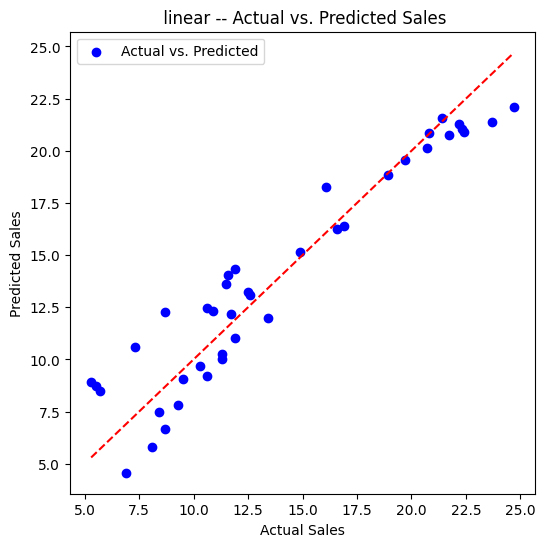

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_test, color='blue', label='Actual vs. Predicted')

plt.plot([y_test.min(),y_test.max()],
         [y_test.min(),y_test.max()],
         'r--')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title(' linear -- Actual vs. Predicted Sales')
plt.legend()
plt.show()

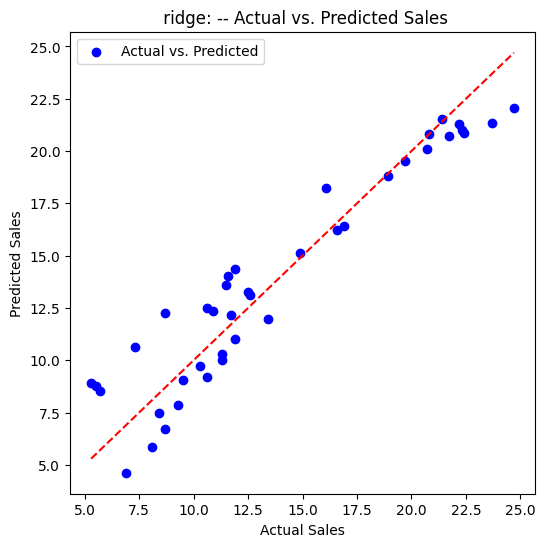

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_test_ridge, color='blue', label='Actual vs. Predicted')

plt.plot([y_test.min(),y_test.max()],
         [y_test.min(),y_test.max()],
         'r--')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title(' ridge: -- Actual vs. Predicted Sales')
plt.legend()
plt.show()

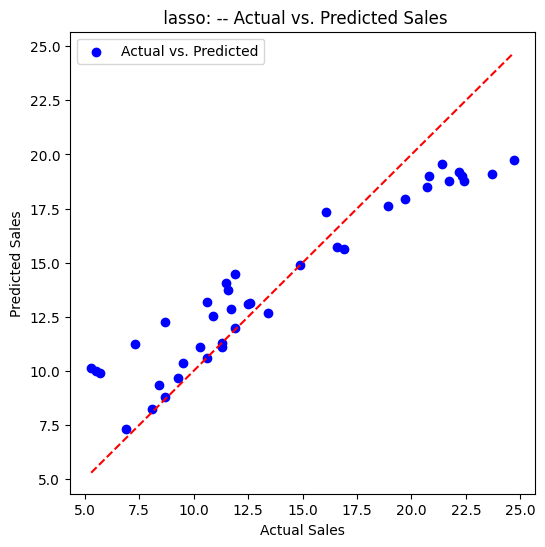

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_test_lasso, color='blue', label='Actual vs. Predicted')

plt.plot([y_test.min(),y_test.max()],
         [y_test.min(),y_test.max()],
         'r--')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title(' lasso: -- Actual vs. Predicted Sales')
plt.legend()
plt.show()

---
## Task 13 - Plot the Residuals

**What to do:**
Residuals are the **errors** made by the model — the difference between actual and predicted values:

$$\text{Residual} = \text{Actual Sales} - \text{Predicted Sales}$$

Steps:
1. Calculate residuals for the test set
2. Plot a histogram with KDE curve to see the distribution of errors

> Subtract `y_pred_test` from `y_test` to get residuals. Use `sns.histplot()` with `kde=True`.


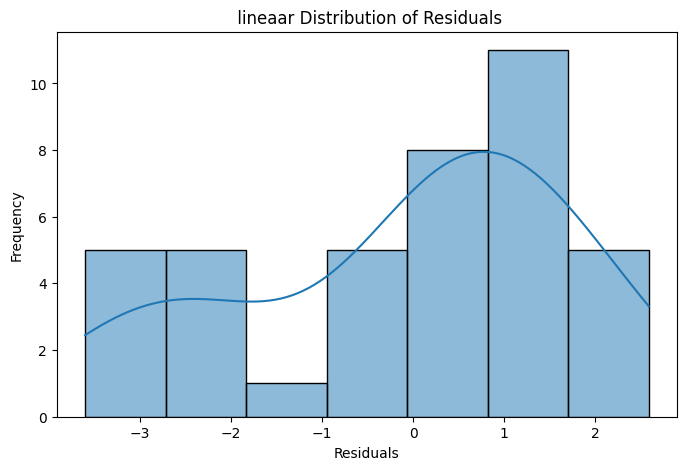

In [ ]:
residuals = y_test - y_pred_test
plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True)
plt.title(' lineaar Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

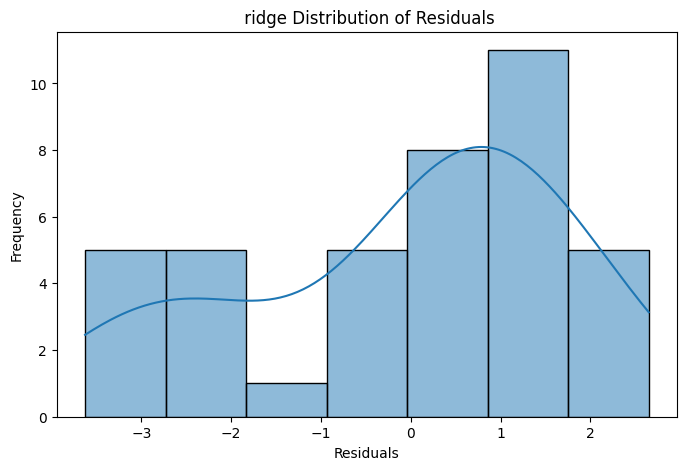

In [ ]:
residuals_ridge = y_test - y_pred_test_ridge
plt.figure(figsize=(8,5))
sns.histplot(residuals_ridge, kde=True)
plt.title(' ridge Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

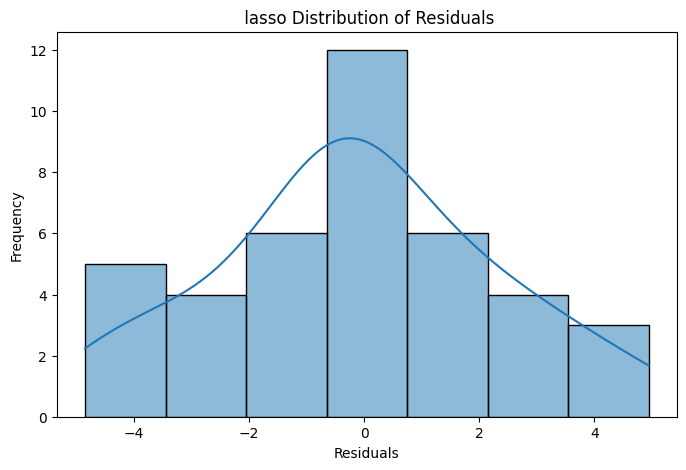

In [ ]:
residuals_lasso = y_test - y_pred_test_lasso
plt.figure(figsize=(8,5))
sns.histplot(residuals_lasso, kde=True)
plt.title(' lasso Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

---

---

---
## Task 14 - Fill the Results Summary Table

After running all your code, fill in the table below with your actual output values. Double-click this cell to edit.

| Metric | Training Set | Test Set |
|---|---|---|
| R² Score | | |
| MSE | — | |
| MAE | — | |



In [ ]:
print("| Metric   | Training Set | Test Set |")
print("|----------|--------------|----------|")
print(f"| R² Score | {r2_score(y_train, y_pred_train):.4f} | {r2_score(y_test, y_pred_test):.4f} |")
print(f"| MSE      | {mean_squared_error(y_train, y_pred_train):.4f} | {mean_squared_error(y_test, y_pred_test):.4f} |")
print(f"| MAE      | {mean_absolute_error(y_train, y_pred_train):.4f} | {mean_absolute_error(y_test, y_pred_test):.4f} |")

| Metric   | Training Set | Test Set |
|----------|--------------|----------|
| R² Score | 0.8957 | 0.8994 |
| MSE      | 2.7051 | 3.1741 |
| MAE      | 1.1985 | 1.4608 |


In [ ]:
print("| Metric   | Training Set | Test Set |")
print("|----------|--------------|----------|")
print(f"| R² Score | {r2_score(y_train, y_pred_train_ridge):.4f} | {r2_score(y_test, y_pred_test_ridge):.4f} |")
print(f"| MSE      | {mean_squared_error(y_train, y_pred_train_ridge):.4f} | {mean_squared_error(y_test, y_pred_test_ridge):.4f} |")
print(f"| MAE      | {mean_absolute_error(y_train, y_pred_train_ridge):.4f} | {mean_absolute_error(y_test, y_pred_test_ridge):.4f} |")

| Metric   | Training Set | Test Set |
|----------|--------------|----------|
| R² Score | 0.8957 | 0.8988 |
| MSE      | 2.7060 | 3.1942 |
| MAE      | 1.1992 | 1.4643 |


In [ ]:
print("| Metric   | Training Set | Test Set |")
print("|----------|--------------|----------|")
print(f"| R² Score | {r2_score(y_train, y_pred_train_lasso):.4f} | {r2_score(y_test, y_pred_test_lasso):.4f} |")
print(f"| MSE      | {mean_squared_error(y_train, y_pred_train_lasso):.4f} | {mean_squared_error(y_test, y_pred_test_lasso):.4f} |")
print(f"| MAE      | {mean_absolute_error(y_train, y_pred_train_lasso):.4f} | {mean_absolute_error(y_test, y_pred_test_lasso):.4f} |")

| Metric   | Training Set | Test Set |
|----------|--------------|----------|
| R² Score | 0.8224 | 0.8180 |
| MSE      | 4.6056 | 5.7447 |
| MAE      | 1.5428 | 1.8549 |


### 15 - Bonus Task: Model Persistence using Joblib

**What to do:**
- Save all trained models using joblib
- Load them again
- Compare their performance on test data

**Objective:**
Understand how models can be reused without retraining.

In [ ]:
import joblib
joblib.dump(linear_model, "linear_model.pkl")


['linear_model.pkl']

In [ ]:
joblib.dump(ridge_model, "ridge_model.pkl")


['ridge_model.pkl']

In [ ]:
joblib.dump(lasso_model, "lasso_model.pkl")

['lasso_model.pkl']

In [ ]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
loaded_linear = joblib.load("linear_model.pkl")
loaded_ridge = joblib.load("ridge_model.pkl")
loaded_lasso = joblib.load("lasso_model.pkl")

In [ ]:
loaded_pred = loaded_linear.predict(X_test_scaled)
loaded_pred_ridge = loaded_ridge.predict(X_test_scaled)
loaded_pred_lasso = loaded_lasso.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("----- Loaded Linear Regression -----")
print("R2 Score:", r2_score(y_test, loaded_pred))
print("MSE:", mean_squared_error(y_test, loaded_pred))
print("MAE:", mean_absolute_error(y_test, loaded_pred))

print("\n----- Loaded Ridge Regression -----")
print("R2 Score:", r2_score(y_test, loaded_pred_ridge))
print("MSE:", mean_squared_error(y_test, loaded_pred_ridge))
print("MAE:", mean_absolute_error(y_test, loaded_pred_ridge))

print("\n----- Loaded Lasso Regression -----")
print("R2 Score:", r2_score(y_test, loaded_pred_lasso))
print("MSE:", mean_squared_error(y_test, loaded_pred_lasso))
print("MAE:", mean_absolute_error(y_test, loaded_pred_lasso))

----- Loaded Linear Regression -----
R2 Score: 0.8994380241009119
MSE: 3.174097353976106
MAE: 1.4607567168117606

----- Loaded Ridge Regression -----
R2 Score: 0.8988025280800618
MSE: 3.194155892207962
MAE: 1.4643012916475109

----- Loaded Lasso Regression -----
R2 Score: 0.8179966490329236
MSE: 5.74467983106347
MAE: 1.8549283137675237


In [ ]:
import joblib
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Save models
joblib.dump(linear_model, "linear_model.pkl")
joblib.dump(ridge_model, "ridge_model.pkl")
joblib.dump(lasso_model, "lasso_model.pkl")

# Load models
loaded_linear = joblib.load("linear_model.pkl")
loaded_ridge = joblib.load("ridge_model.pkl")
loaded_lasso = joblib.load("lasso_model.pkl")

# Predictions using loaded models
loaded_pred_lr = loaded_linear.predict(X_test_scaled)
loaded_pred_ridge = loaded_ridge.predict(X_test_scaled)
loaded_pred_lasso = loaded_lasso.predict(X_test_scaled)

# Compare performance
print("----- Loaded Linear Regression -----")
print("R2 Score:", r2_score(y_test, loaded_pred_lr))
print("MSE:", mean_squared_error(y_test, loaded_pred_lr))
print("MAE:", mean_absolute_error(y_test, loaded_pred_lr))

print("\n----- Loaded Ridge Regression -----")
print("R2 Score:", r2_score(y_test, loaded_pred_ridge))
print("MSE:", mean_squared_error(y_test, loaded_pred_ridge))
print("MAE:", mean_absolute_error(y_test, loaded_pred_ridge))

print("\n----- Loaded Lasso Regression -----")
print("R2 Score:", r2_score(y_test, loaded_pred_lasso))
print("MSE:", mean_squared_error(y_test, loaded_pred_lasso))
print("MAE:", mean_absolute_error(y_test, loaded_pred_lasso))

----- Loaded Linear Regression -----
R2 Score: 0.8994380241009119
MSE: 3.174097353976106
MAE: 1.4607567168117606

----- Loaded Ridge Regression -----
R2 Score: 0.8988025280800618
MSE: 3.194155892207962
MAE: 1.4643012916475109

----- Loaded Lasso Regression -----
R2 Score: 0.8179966490329236
MSE: 5.74467983106347
MAE: 1.8549283137675237


In [ ]:
88788887799654123

88788887799654123